#### Imports 

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp
from ode_solver import euler, RungeKutta, TestEuler, TestRungeKutta 

In [2]:
print("Running Tests from ode_solver.py\n")

# Define the ODE and exact solution
f = lambda t, y: y - t**2 + 1
exact = lambda t: (t + 1)**2 - 0.5 * np.exp(t)

# Test Euler directly
print("Calling Euler directly:")
t, y = euler(f, 0, 0.5, 2, 0.25)
print(f"Final approximation: y(2) ≈ {y[-1][0]:.6f}, true = {exact(2):.6f}\n")

# Test Runge–Kutta directly
print("Calling Runge–Kutta directly:")
t, y = RungeKutta(f, 0, 0.5, 2, 0.25)
print(f"Final approximation: y(2) ≈ {y[-1][0]:.6f}, true = {exact(2):.6f}\n")

# Run automated tests
try:
    TestEuler()
    TestRungeKutta()
    print("\nAll ODE tests passed successfully!\n")
except AssertionError as e:
    print("\n--- A TEST FAILED ---")
    print(e)

Running Tests from ode_solver.py

Calling Euler directly:
Final approximation: y(2) ≈ 4.779652, true = 5.305472

Calling Runge–Kutta directly:
Final approximation: y(2) ≈ 5.305210, true = 5.305472


--- Testing Euler Method ---

h = 0.5      → y(2) ≈ 4.437500, true = 5.305472, error = 8.68e-01
h = 0.25     → y(2) ≈ 4.779652, true = 5.305472, error = 5.26e-01
h = 0.125    → y(2) ≈ 5.010469, true = 5.305472, error = 2.95e-01
h = 0.0625   → y(2) ≈ 5.148250, true = 5.305472, error = 1.57e-01

Euler plot saved as 'euler_convergence.png'
Estimated order of convergence ≈ 0.82


--- Testing Runge–Kutta 4th Order Method ---

h = 0.5      → y(2) ≈ 5.301605, true = 5.305472, error = 3.87e-03
h = 0.25     → y(2) ≈ 5.305210, true = 5.305472, error = 2.62e-04
h = 0.125    → y(2) ≈ 5.305455, true = 5.305472, error = 1.70e-05
h = 0.0625   → y(2) ≈ 5.305471, true = 5.305472, error = 1.08e-06

Runge–Kutta plot saved as 'runge_kutta_convergence.png'
Estimated order of convergence ≈ 3.94


All ODE tests p

#### Exercise 1 

##### Use Euler/RK4's method to approximate/plot the solutions for each of the following initial-value problems. (Plot your solution for all the values of t)
1. $y'=3e^{-ty}$, $1\leq t \leq 3$, $y(0)=1/2$, with $h=0.005$
2. $y'=\frac{1+t^2}{1+2y}$, $2\leq t \leq 5$, $y(2)=3$, with $h=0.01$
3. $y' = t^{2}\sin(y)$, $0 \leq t \leq 4$, $y(0) = 2$, with $h=0.001$
4. $ y' = \frac{t^3}{y},\; 1 < t < 10, \; y(1) = 1$, with $h=0.002$

In [3]:
# Problem 1: y' = 3 * e^(-t * y)
def f1(t, y):
    return 3 * np.exp(-t * y)

# Problem 2: y' = (1 + t^2) / (1 + 2y)
def f2(t, y):
    return (1 + t**2) / (1 + 2 * y)

# Problem 3: y' = t^2 * sin(y)
def f3(t, y):
    return (t**2) * (np.sin(y))

# Problem 4: y' = t^3 / y
def f4(t, y):
    return (t**3) / y


In [4]:
approximation = [
    (f1, 1, 0.5, 3, 0.005, "y' = 3e^(-ty)"),
    (f2, 2, 3, 5, 0.01, "y' = (1 + t²) / (1 + 2y)"),
    (f3, 0, 2, 4, 0.001, "y' = t² sin(y)"),
    (f4, 1, 1, 10, 0.002, "y' = t³ / y")
]

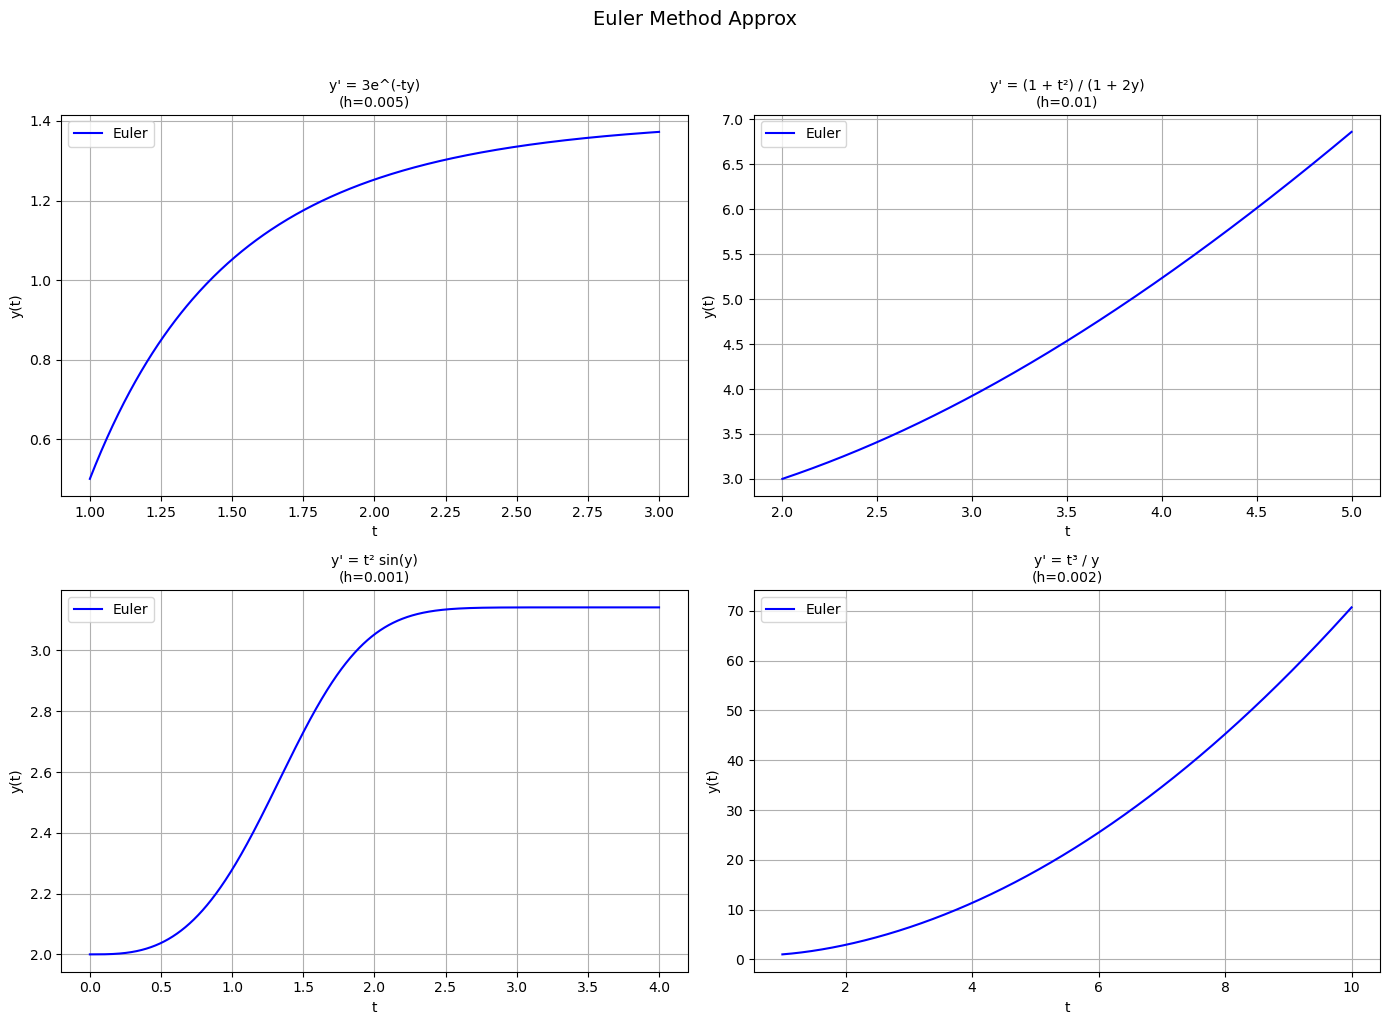

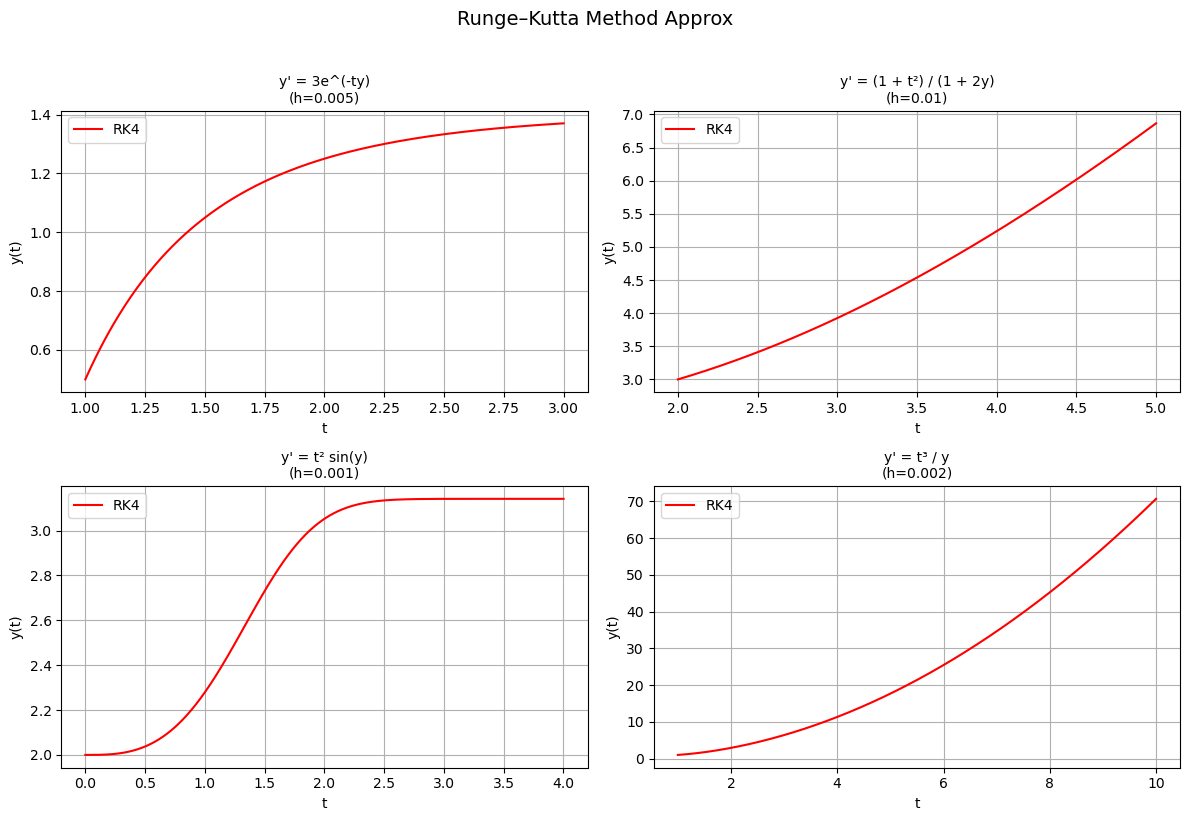

In [5]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (f, t0, y0, t_end, h, label) in zip(axes, approximation):
    t_euler, y_euler = euler(f, t0, y0, t_end, h)
    ax.plot(t_euler, y_euler, 'b-', label='Euler')
    ax.set_title(f"{label}\n(h={h})", fontsize=10)
    ax.set_xlabel("t")
    ax.set_ylabel("y(t)")
    ax.grid(True)
    ax.legend()

fig.suptitle("Euler Method Approx", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, (f, t0, y0, t_end, h, label) in zip(axes, approximation):
    t_rk, y_rk = RungeKutta(f, t0, y0, t_end, h)
    ax.plot(t_rk, y_rk, 'r-', label='RK4')
    ax.set_title(f"{label}\n(h={h})", fontsize=10)
    ax.set_xlabel("t")
    ax.set_ylabel("y(t)")
    ax.grid(True)
    ax.legend()

fig.suptitle("Runge–Kutta Method Approx", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Exercise 2 

##### Use Euler/RK4's method to approximate/plot the solutions for each of the following initial-value problem.
$$ y'= \frac{2-2ty}{t^2+1}, ~~~~ 1\leq t \leq 4, ~~~~ y(1)=2$$
The actual solutions to the initial-value is
$$y(t)=\frac{2t+2}{t^2+1}.$$
1. Compute/plot the error of your approximation and bound the error for $1\leq t
\leq 4$, for $h=0.01, 0.005, 0.001$


In [6]:
# Define the ODE and exact solution
def f(t, y):
    return (2 - 2 * t * y) / (t**2 + 1)

def exact_y(t):
    return (2 * t + 2) / (t**2 + 1)

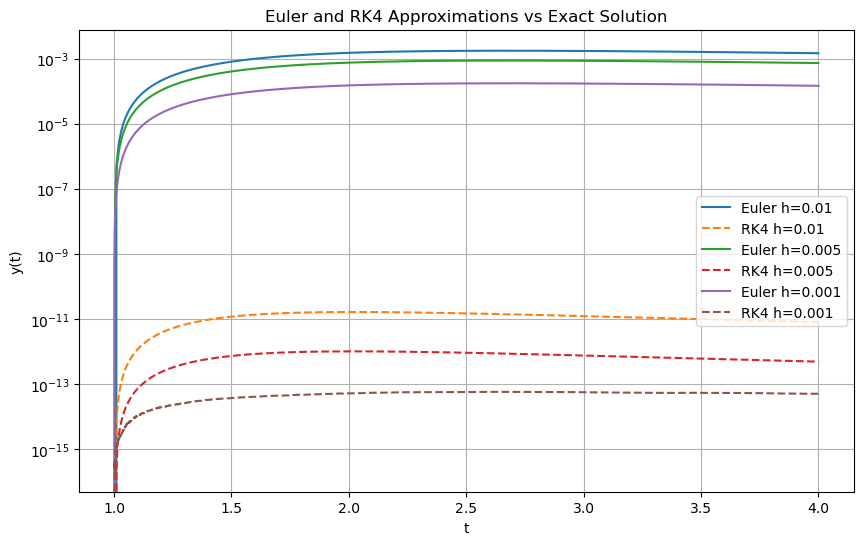

In [7]:
t0, y0, t_end = 1, 2, 4
hs = [0.01, 0.005, 0.001]
plt.figure(figsize=(10, 6))

for h in hs:
    # Compute approximations
    t_e, y_e = euler(f, t0, y0, t_end, h)
    t_r, y_r = RungeKutta(f, t0, y0, t_end, h)
    
    # Last points
    t_last = t_e[-1]
    y_e_last = y_e[-1]
    y_r_last = y_r[-1]
    error_e_last = abs(y_e_last - exact_y(t_last))
    error_r_last = abs(y_r_last - exact_y(t_last))
    
    error_e = np.abs( y_e[ :, 0] - exact_y(t_e))
    error_r = np.abs( y_r[ :, 0] - exact_y(t_r))
    
    # Plot approximations
    plt.plot(t_e, error_e, label="Euler h="+str(h))
    plt.plot(t_r, error_r, '--', label="RK4 h="+str(h))
    
    
plt.xlabel("t")
plt.ylabel("y(t)")
plt.yscale('log')
plt.title("Euler and RK4 Approximations vs Exact Solution")
plt.legend(loc='center right')
plt.grid(True)
plt.show()
    

2. Approximate $y(4)$ for for $h=0.01, 0.005, 0.001$ and compute the error.

In [8]:
# Initial conditions and step sizes
t0, y0, t_end = 1, 2, 4
hs = [0.01, 0.005, 0.001]

# Exact value at t=4
exact_y_4 = 10/17  # ≈0.588235

plt.figure(figsize=(10,6))

for h in hs:
    # Compute approximations
    t_e, y_e = euler(f, t0, y0, t_end, h)
    t_r, y_r = RungeKutta(f, t0, y0, t_end, h)
    
    # Last points
    y_e_last = y_e[-1]
    y_r_last = y_r[-1]
    error_e_last = abs(y_e_last - exact_y_4)
    error_r_last = abs(y_r_last - exact_y_4)
    
    # Print last-point approximations and errors
    print("\nStep size h =", h)
    print("Euler y(4) =", y_e_last, "Euler error =", error_e_last)
    print("RK4 y(4) =", y_r_last, "RK4 error =", error_r_last)
    

# Print the exact value
print("\nExact y(4) =", exact_y_4, "≈ 0.588235")



Step size h = 0.01
Euler y(4) = [0.58675547] Euler error = [0.00147982]
RK4 y(4) = [0.58823529] RK4 error = [8.13316081e-12]

Step size h = 0.005
Euler y(4) = [0.58749548] Euler error = [0.00073981]
RK4 y(4) = [0.58823529] RK4 error = [5.08038056e-13]

Step size h = 0.001
Euler y(4) = [0.58792825] Euler error = [0.00030705]
RK4 y(4) = [0.58807616] RK4 error = [0.00015913]

Exact y(4) = 0.5882352941176471 ≈ 0.588235


<Figure size 1000x600 with 0 Axes>

#### Exercise 3

##### Given the initial-value problem
$$y'=te^{-t}-y,\; 0\leq t \leq 5, \; y(0)=1$$
Approximate y(5) using Euler/RK4's method with h = 0.1, h =0.01, and h = 0.001.

In [9]:
def f_3(t, y):
    return t * np.exp(-t) - y 

In [10]:
#Finding the ext y(t)
def exact_y3(t):
    return np.exp(-t) * (0.5 * t**2 + 1)


Step size h = 0.1
Euler y(4) = [0.0890385] Euler error = [0.37249996]
RK4 y(4) = [0.09096232] RK4 error = [0.37057614]

Step size h = 0.01
Euler y(4) = [0.09076617] Euler error = [0.37077229]
RK4 y(4) = [0.09096228] RK4 error = [0.37057618]

Step size h = 0.001
Euler y(4) = [0.09094264] Euler error = [0.37059583]
RK4 y(4) = [0.09096228] RK4 error = [0.37057618]


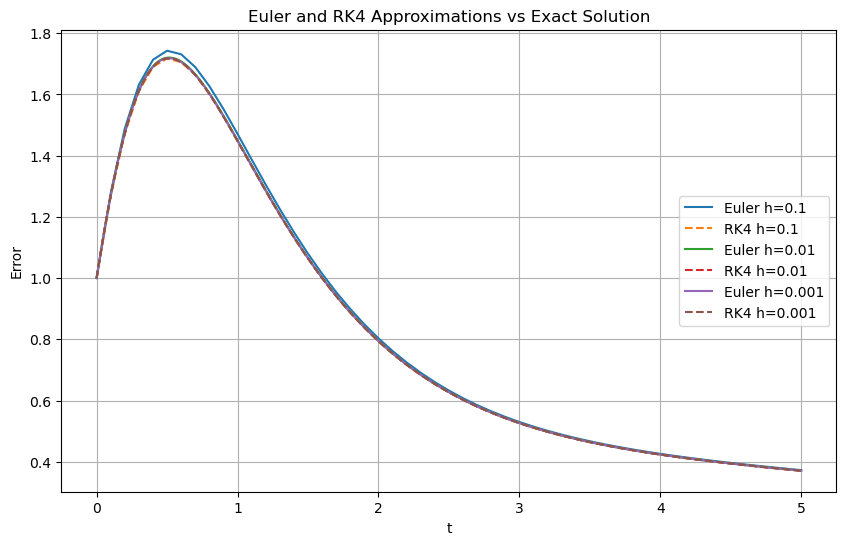

In [11]:
t0, y0, t_end = 0, 1, 5
hs = [0.1, 0.01, 0.001]
plt.figure(figsize=(10, 6))

for h in hs:
    # Compute approximations
    t_e, y_e = euler(f_3, t0, y0, t_end, h)
    t_r, y_r = RungeKutta(f_3, t0, y0, t_end, h)
    
    # Last points
    t_last = t_e[-1]
    y_e_last = y_e[-1]
    y_r_last = y_r[-1]
    error_e_last = np.abs(y_e_last - exact_y(t_last))
    error_r_last = np.abs(y_r_last - exact_y(t_last))
    
    error_e = np.abs( y_e[ :, 0] - exact_y(t_e))
    error_r = np.abs( y_r[ :, 0] - exact_y(t_r))

    # Print last-point approximations and errors
    print("\nStep size h =", h)
    print("Euler y(4) =", y_e_last, "Euler error =", error_e_last)
    print("RK4 y(4) =", y_r_last, "RK4 error =", error_r_last)
    
    
    # Plot approximations
    plt.plot(t_e, error_e, label="Euler h="+str(h))
    plt.plot(t_r, error_r, '--', label="RK4 h="+str(h))
    
    
plt.xlabel("t")
plt.ylabel("Error")
plt.title("Euler and RK4 Approximations vs Exact Solution")
plt.legend(loc='center right')
plt.grid(True)
plt.show()


#### Exercise 4

##### Test the [scipy.integrate.solve_ivp](https://docs.scipy.org/doc/scipy/reference/ generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp)

In [12]:
def test_function(t,y):
    return t * np.exp(-t) - y

def exact_test(t):
    return np.exp(-t) * (0.5 * t**2 + 1)

In [13]:
# Solve using solve_ivp with RK45
t0, y0, t_end = 0, 1, 5
t_points = np.linspace(t0, t_end, 200)
sol = solve_ivp(fun=test_function, t_span=[t0, t_end], y0=[y0], t_eval=t_points)

# Compute the exact solution and error
y_exact = exact_test(t_points)
error = np.abs(sol.y[0] - y_exact)

In [14]:
print(f"Final value at t=5:")
print(f"solve_ivp approximation: {sol.y[0][-1]:.8f}")
print(f"Exact value:             {y_exact[-1]:.8f}")
print(f"Absolute error:          {abs(sol.y[0][-1] - y_exact[-1]):.2e}")

Final value at t=5:
solve_ivp approximation: 0.09100441
Exact value:             0.09096228
Absolute error:          4.21e-05


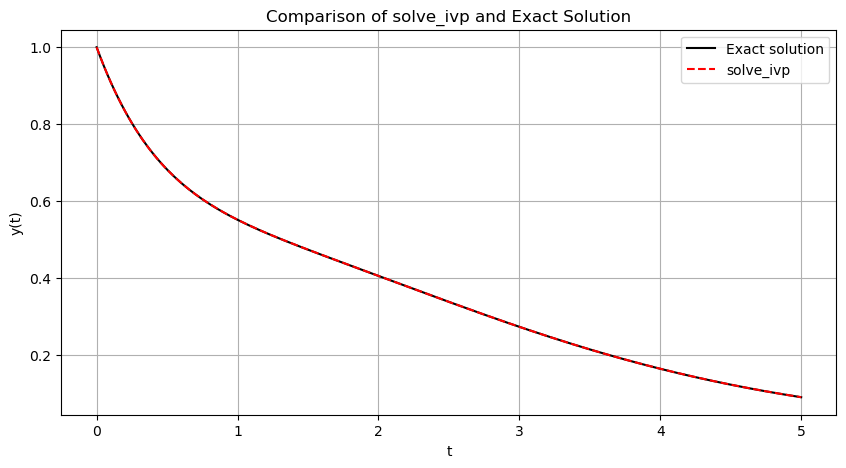

In [15]:
# Plot numerical vs exact
plt.figure(figsize=(10, 5))
plt.plot(t_points, y_exact, 'k-', label="Exact solution")
plt.plot(sol.t, sol.y[0], 'r--', label="solve_ivp")
plt.title("Comparison of solve_ivp and Exact Solution")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()

#### Exercise 5 

##### Lokta-Volterra Equations:
$$\begin{cases}
& \displaystyle{\frac{dx}{dt} = \alpha x - \beta xy } \\
& \displaystyle{\frac{dy}{dt} = \delta xy - \gamma y}
\end{cases}$$
where
* x is the number of prey
* y is the number of some predator
* $\alpha$, $\beta$, $\gamma$, $\delta$ are positive real parameters describing the
interaction of the two species.
* The prey are assumed to have an unlimited food supply and to reproduce
exponentially, unless subject to predation; this exponential growth is represented
in the equation above by the term $\alpha x$.
* The rate of predation upon the prey is represented above by $\beta xy$. If either
x or y is zero, then there can be no predation.
* $\delta xy$ represents the growth of the predator population.
* $\gamma y$ represents the loss rate of the predators due to either natural death
or emigration, it leads to an exponential decay in the absence of prey

1. Solve the Lokta-Volterra equations with the 2 different methods, with $\alpha= 1/3$, $\beta = 3/4$, $\gamma = 1 = \delta$

In [16]:
# Parameters
alpha = 1/3
beta = 3/4
gamma = 1
delta = 1

In [17]:
# Lotka-Volterra system
def f(t, X):
    x, y = X
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return np.array([dxdt, dydt])

In [18]:
t0, t_end = 0, 30
h = 0.01
X0 = np.array([2, 1])

t_e, X_e = euler(f, t0, X0, t_end, h)
t_rk4, X_rk4 = RungeKutta(f, t0, X0, t_end, h)

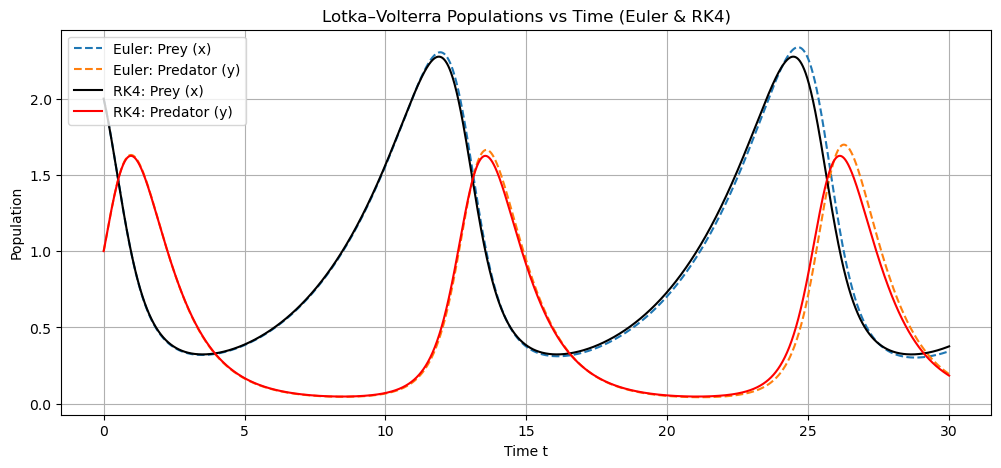

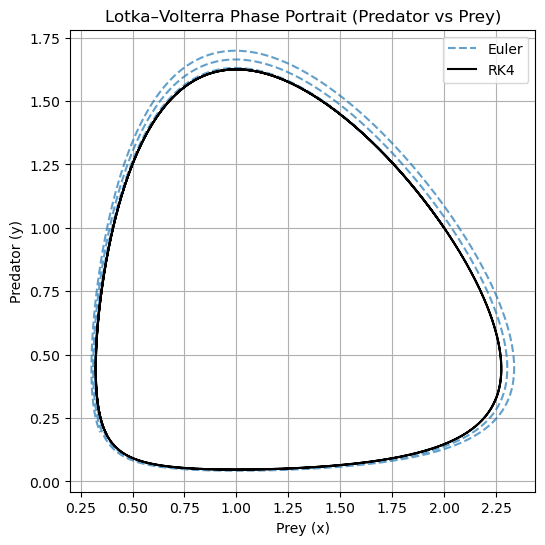


--- Lotka–Volterra Results ---
Step size h = 0.01
t	Euler x	     Euler y	      RK4 x	      RK4 y
30.0	0.343891	0.193830	0.375842	0.183858


In [19]:
plt.figure(figsize=(12, 5))
plt.plot(t_e, X_e[:, 0], '--', label='Euler: Prey (x)')
plt.plot(t_e, X_e[:, 1], '--', label='Euler: Predator (y)')
plt.plot(t_rk4, X_rk4[:, 0], '-', color='black', label='RK4: Prey (x)')
plt.plot(t_rk4, X_rk4[:, 1], '-', color='red', label='RK4: Predator (y)')
plt.title("Lotka–Volterra Populations vs Time (Euler & RK4)")
plt.xlabel("Time t")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(X_e[:, 0], X_e[:, 1], '--', alpha=0.7, label='Euler')
plt.plot(X_rk4[:, 0], X_rk4[:, 1], '-', color='black', label='RK4')
plt.title("Lotka–Volterra Phase Portrait (Predator vs Prey)")
plt.xlabel("Prey (x)")
plt.ylabel("Predator (y)")
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Lotka–Volterra Results ---")
print(f"Step size h = {h}")
print("t\tEuler x\t     Euler y\t      RK4 x\t      RK4 y")
print(f"{t_e[-1]}\t{X_e[-1,0]:.6f}\t{X_e[-1,1]:.6f}\t{X_rk4[-1,0]:.6f}\t{X_rk4[-1,1]:.6f}")

2. Try another cool set of value and solve it

In [20]:
# Parameters
alpha = 1/4
beta = 3/5
gamma = 3
delta = 3

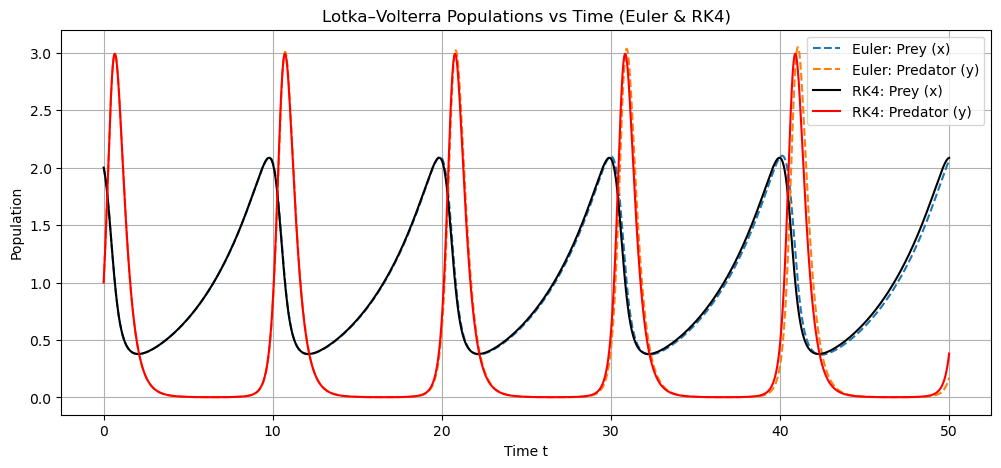

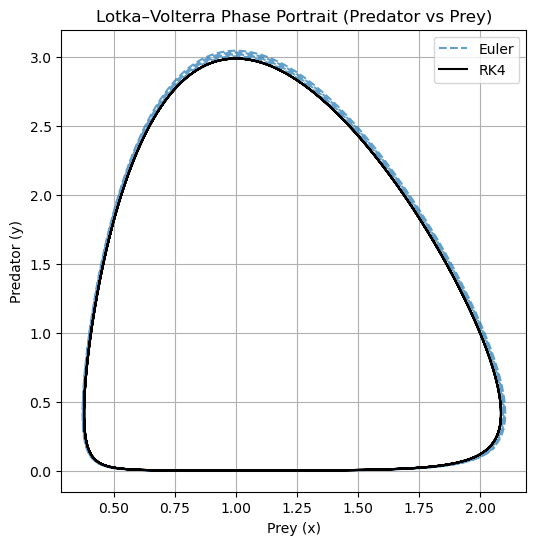


--- Lotka–Volterra Results ---
Step size h = 0.01
t	Euler x	     Euler y	      RK4 x	      RK4 y
50.000	2.060036	0.172654	2.085049	0.381911


In [21]:
# Lotka-Volterra system
t0_2, t_end_2 = 0, 50
h_2 = 0.001
X0_2 = np.array([2, 1])

t_e, X_e = euler(f, t0_2, X0_2, t_end_2, h_2)
t_rk4, X_rk4 = RungeKutta(f, t0_2, X0_2, t_end_2, h_2)

plt.figure(figsize=(12, 5))
plt.plot(t_e, X_e[:, 0], '--', label='Euler: Prey (x)')
plt.plot(t_e, X_e[:, 1], '--', label='Euler: Predator (y)')
plt.plot(t_rk4, X_rk4[:, 0], '-', color='black', label='RK4: Prey (x)')
plt.plot(t_rk4, X_rk4[:, 1], '-', color='red', label='RK4: Predator (y)')
plt.title("Lotka–Volterra Populations vs Time (Euler & RK4)")
plt.xlabel("Time t")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(X_e[:, 0], X_e[:, 1], '--', alpha=0.7, label='Euler')
plt.plot(X_rk4[:, 0], X_rk4[:, 1], '-', color='black', label='RK4')
plt.title("Lotka–Volterra Phase Portrait (Predator vs Prey)")
plt.xlabel("Prey (x)")
plt.ylabel("Predator (y)")
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Lotka–Volterra Results ---")
print(f"Step size h = {h}")
print("t\tEuler x\t     Euler y\t      RK4 x\t      RK4 y")
print(f"{t_e[-1]:.3f}\t{X_e[-1,0]:.6f}\t{X_e[-1,1]:.6f}\t{X_rk4[-1,0]:.6f}\t{X_rk4[-1,1]:.6f}")

#### Exercise 6 

##### Solve the pendulum equations
$$\begin{cases}
\frac{d\theta}{dt} &= \omega \\
\frac{d\omega}{dt} &=\frac{b}{m}\omega + \frac{g}{L}\sin(\theta)
\end{cases}$$
with
* $L$ is the length of the pendulum
* $\theta$ is the angle
* $b$ is the damping coefficient
* $g$ is the gravity
![Alt text](https://external-content.duckduckgo.com/iu/?
u=https%3A%2F%2Faleksandarhaber.com%2Fwp-
content%2Fuploads%2F2020%2F03%2Fpendulum1.jpg&f=1&nofb=1&ipt=66ff055ec65998da85ef49
9095f3b9d6602cec3fe7fb3c6b1550054043ef99ea&ipo=images)
For our case we can pick $L=1$, $b=0.05$, $g=9.81$, $m=1$. Start with
$\theta=\pi/2$ and solve the ODE. Try with a different starting $\theta$ and solve
the ODE.

In [22]:
# Parameters
L = 1
b = 0.05
g = 9.81
m = 1

In [23]:
def pendulum(t, y):
    theta, omega = y
    dtheta = omega
    domega = -(b/m) * omega - (g/L) * np.sin(theta)
    return np.array([dtheta, domega]) 

In [24]:
# Simulation parameters
t0, t_end = 0, 20
h = 0.01
theta0_values = [np.pi/2, np.pi/4]


--- Pendulum Results for θ₀ = 1.571 rad ---
Step size h = 0.01
t_end	    Euler θ	    Euler ω	    RK4 θ	    RK4 ω	   SciPy θ	  SciPy ω
20.010	1.735957	-1.852128	0.865578	-0.848749	0.873693	-0.774194


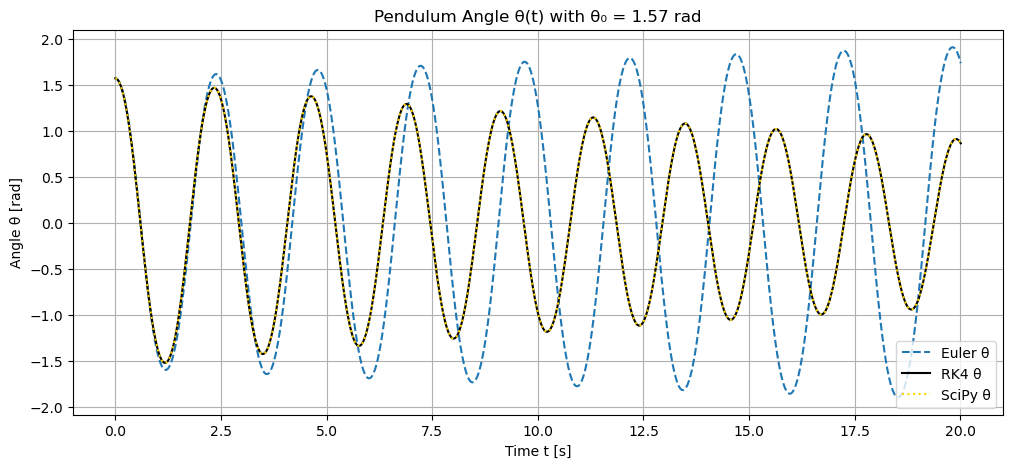

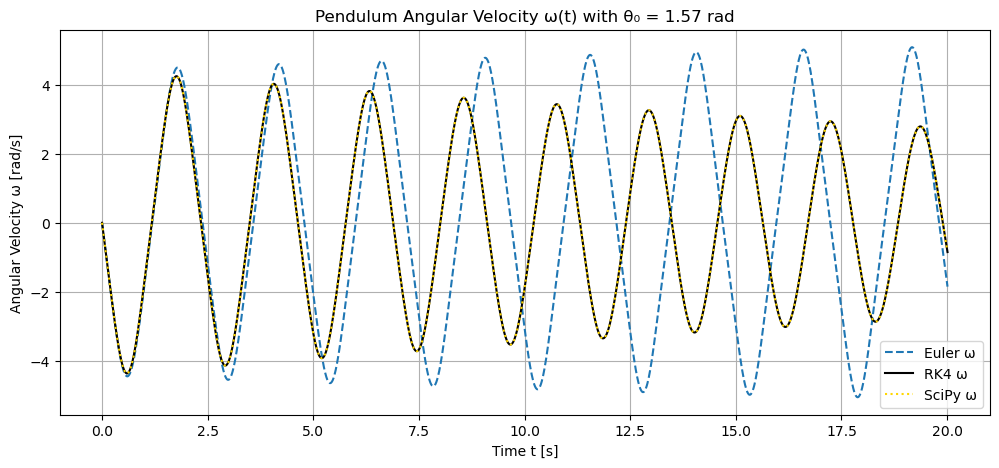


--- Pendulum Results for θ₀ = 0.785 rad ---
Step size h = 0.01
t_end	    Euler θ	    Euler ω	    RK4 θ	    RK4 ω	   SciPy θ	  SciPy ω
20.010	-0.886731	-2.122843	-0.050495	1.455265	-0.065024	1.450329


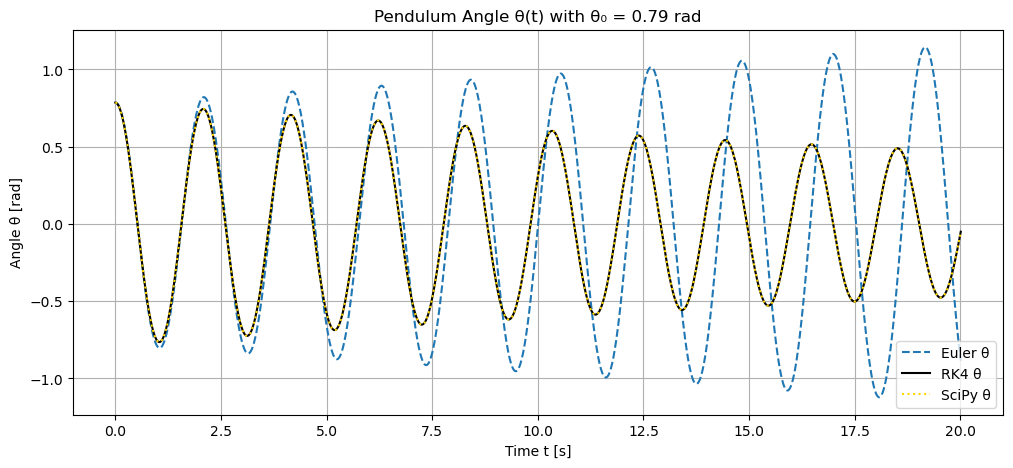

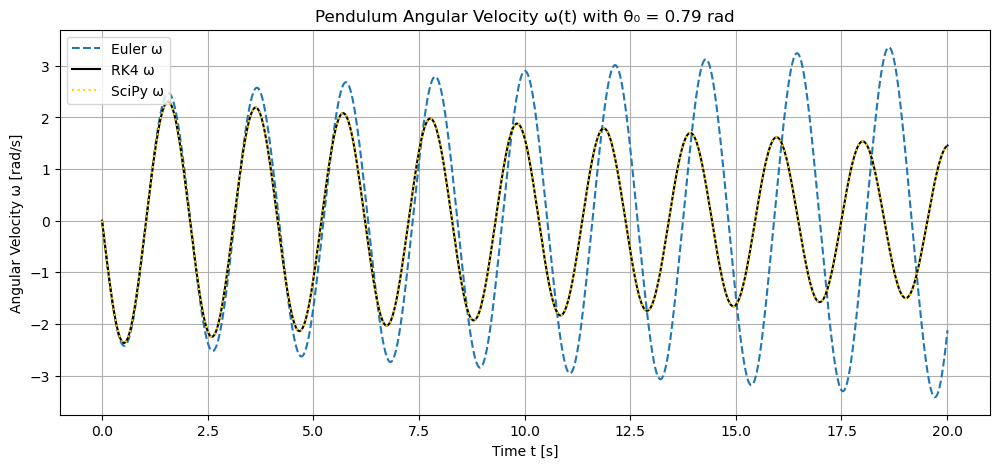

In [25]:
# Loop through different initial angles
for theta0 in theta0_values:
    y0 = np.array([theta0, 0.0])

    # Numerical solutions
    t_e, X_e = euler(pendulum, t0, y0, t_end, h)
    t_r, X_r = RungeKutta(pendulum, t0, y0, t_end, h)

    # Ground truth using SciPy
    sol = solve_ivp(pendulum, (t0, t_end), y0,
                    t_eval=np.linspace(t0, t_end, int((t_end-t0)/h)+1),
                    rtol=1e-10, atol=1e-10)
    t_s, X_s = sol.t, sol.y.T

    # Extract final values
    theta_s, omega_s = X_s[-1, 0], X_s[-1, 1]

     # Print summary
    print(f"\n--- Pendulum Results for θ₀ = {theta0:.3f} rad ---")
    print(f"Step size h = {h}")
    print("t_end\t    Euler θ\t    Euler ω\t    RK4 θ\t    RK4 ω\t   SciPy θ\t  SciPy ω")
    print(f"{t_e[-1]:.3f}\t{X_e[-1,0]:.6f}\t{X_e[-1,1]:.6f}\t"
          f"{X_r[-1,0]:.6f}\t{X_r[-1,1]:.6f}\t"
          f"{theta_s:.6f}\t{omega_s:.6f}")

    # Plot θ(t)
    plt.figure(figsize=(12,5))
    plt.plot(t_e, X_e[:,0], label="Euler θ", linestyle="--")
    plt.plot(t_r, X_r[:,0], label="RK4 θ", color='black')
    plt.plot(t_s, X_s[:,0], label="SciPy θ", linestyle=":", color='gold')
    plt.title(f"Pendulum Angle θ(t) with θ₀ = {theta0:.2f} rad")
    plt.xlabel("Time t [s]")
    plt.ylabel("Angle θ [rad]")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot ω(t)
    plt.figure(figsize=(12,5))
    plt.plot(t_e, X_e[:,1], label="Euler ω", linestyle="--")
    plt.plot(t_r, X_r[:,1], label="RK4 ω", color='black')
    plt.plot(t_s, X_s[:,1], label="SciPy ω", linestyle=":", color='gold')
    plt.title(f"Pendulum Angular Velocity ω(t) with θ₀ = {theta0:.2f} rad")
    plt.xlabel("Time t [s]")
    plt.ylabel("Angular Velocity ω [rad/s]")
    plt.legend()
    plt.grid(True)
    plt.show()

#### Bonus 

#### Exercise 7

##### The SIR model. To learn more you can see [Compartemental
Model](https://en.wikipedia.org/wiki/Compartmental_models_in_epidemiology) or [SIR
Modeling - Western Kentucky University
](https://people.wku.edu/lily.popova.zhuhadar/)
* $S(t)$: the number of individuals susceptible of contracting the infection at
time $t$,
* $I(t)$: the number of individuals that are alive and infected at time t;
* $R(t)$: the cumulative number of individuals that recovered from the disease up
to time t;
In addition, $N$ is the total number of people in the area at time $t$ with $N =
S(t) + I(t) + R(t)$.
The SIR model is given by the following expressions:
$$
\begin{equation}
\begin{split}
\dfrac{dS}{dt} &= -\frac{\beta I S}{N}, \\
\dfrac{dI}{dt} &= \frac{\beta I S}{N} - \gamma I\\
\dfrac{dR}{dt} &= \gamma I,\\
\end{split}
\end{equation}
$$
#### Part I
Pick $\beta=0.2$, $\gamma=1/10$, $N=1000$, $I(0)=1$, solve this epidemic problem.
What is the percentage of Recovered/Immuned indivual needed for the desease to stop
spreading?

In [26]:
# Parameters
beta = 0.2
gamma = 0.1
N = 1000
I0 = 1
S0 = N - I0
R0 = 0

# SIR system
def sir(t, y):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

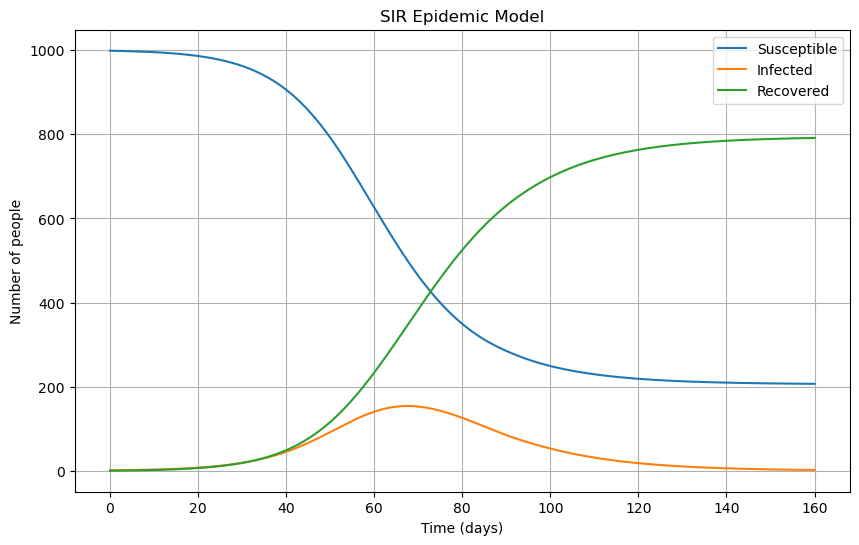

In [27]:
# Time span
t_span = [0, 160]
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Solve ODE
sol = solve_ivp(sir, t_span, [S0, I0, R0], t_eval=t_eval)

S, I, R = sol.y

# Plot
plt.figure(figsize=(10,6))
plt.plot(t_eval, S, label='Susceptible')
plt.plot(t_eval, I, label='Infected')
plt.plot(t_eval, R, label='Recovered')
plt.xlabel('Time (days)')
plt.ylabel('Number of people')
plt.title('SIR Epidemic Model')
plt.legend()
plt.grid()
plt.show()

##### Part II
Find and model the spread of specific desease/infection using the SIR model.

In [28]:
# Parameters (Measles)
R0_measles = 15           
gamma = 1 / 7            
beta = R0_measles * gamma 
N = 1000
I0 = 1
S0 = N - I0
R0_init = 0

# SIR system
def sir_measles(t, y):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]


In [29]:
# Time span and points
t_span = [0, 160]
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Solve ODE
sol = solve_ivp(sir_measles, t_span, [S0, I0, R0_init], t_eval=t_eval)
S, I, R = sol.y

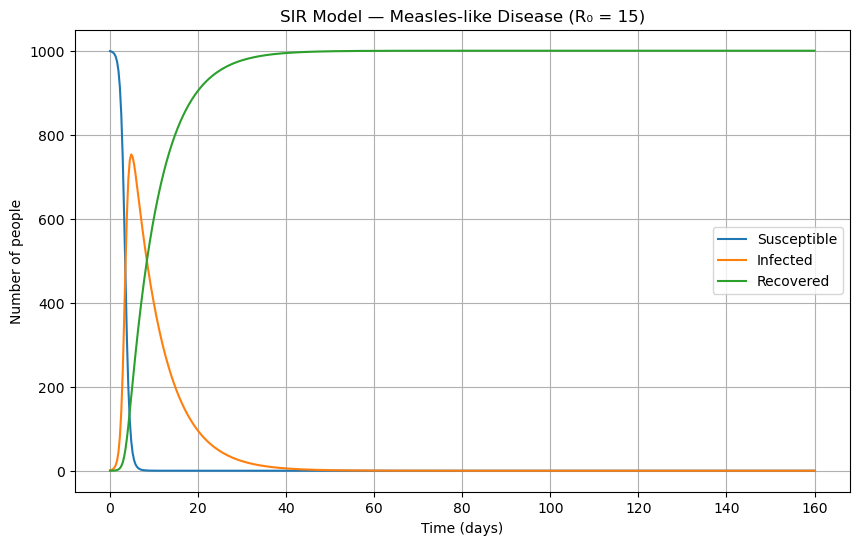

R₀ = 15.00
Herd immunity threshold = 93.33%
Peak infected = 753.0 people on day 4.8
Final recovered = 1000.0 (100.00%)


In [30]:
# Plot
plt.figure(figsize=(10,6))
plt.plot(t_eval, S, label='Susceptible')
plt.plot(t_eval, I, label='Infected')
plt.plot(t_eval, R, label='Recovered')
plt.xlabel('Time (days)')
plt.ylabel('Number of people')
plt.title('SIR Model — Measles-like Disease (R₀ = 15)')
plt.legend()
plt.grid()
plt.show()

# Print key results
herd_threshold = 1 - 1 / R0_measles
peak_I = np.max(I)
peak_day = t_eval[np.argmax(I)]
final_R = R[-1]

print(f"R₀ = {R0_measles:.2f}")
print(f"Herd immunity threshold = {herd_threshold*100:.2f}%")
print(f"Peak infected = {peak_I:.1f} people on day {peak_day:.1f}")
print(f"Final recovered = {final_R:.1f} ({final_R/N*100:.2f}%)")

#### Exercise 8

##### Use the Euler Implicit method to approximate/plot the solutions to each of the
following initial-value. See [Euler
Implicite](https://en.wikipedia.org/wiki/Backward_Euler_method).
1. $y' = -ty + 4t/y$, $0 \leq t \leq 1$, $y(0) = 1$, with $h = 0.1$


In [31]:
# Parameters
h = 0.1
t0, t_end = 0, 1
y0 = 1

# Time grid
t_values = np.arange(t0, t_end + h, h)
N = len(t_values)
y = np.zeros(N)
y[0] = y0

In [32]:
# Implicit (Backward) Euler iteration
for n in range(N - 1):
    t_next = t_values[n + 1]
    
    # From implicit formula: (1 + h*t_{n+1}) y_{n+1}^2 - y_n y_{n+1} - 4h t_{n+1} = 0
    a = 1 + h * t_next
    b = -y[n]
    c = -4 * h * t_next
    
    # Solve quadratic equation a*y^2 + b*y + c = 0
    disc = b**2 - 4*a*c
    sqrt_disc = np.sqrt(max(disc, 0))  # protect from tiny negatives
    
    y1 = (-b + sqrt_disc) / (2*a)
    y2 = (-b - sqrt_disc) / (2*a)
    
    # choose the root that's positive and closest to previous y
    candidates = np.array([y1, y2])
    positive = candidates[candidates > 0]
    if positive.size > 0:
        y[n+1] = positive[np.argmin(np.abs(positive - y[n]))]
    else:
        y[n+1] = candidates[np.argmin(np.abs(candidates - y[n]))]


 n    t      y
 0  0.0  1.000000
 1  0.1  1.028602
 2  0.2  1.080988
 3  0.3  1.150746
 4  0.4  1.231421
 5  0.5  1.317370
 6  0.6  1.404059
 7  0.7  1.488059
 8  0.8  1.566927
 9  0.9  1.639051
10  1.0  1.703510


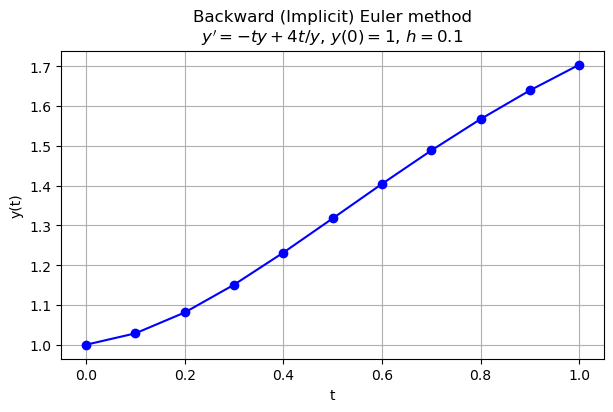

In [33]:
# Print results
print(" n    t      y")
for n in range(N):
    print(f"{n:2d}  {t_values[n]:.1f}  {y[n]:.6f}")

# Plot
plt.figure(figsize=(7,4))
plt.plot(t_values, y, marker='o', linestyle='-', color='b')
plt.title("Backward (Implicit) Euler method\n$y'=-ty+4t/y$, $y(0)=1$, $h=0.1$")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)
plt.show()

2. $y' = \frac{y^2+y}{t}$, $1 \leq t \leq 3$, $y(l) = -2$, with $h = 0.2$

In [34]:
# Parameters
h = 0.2
t0, t_end = 1, 3
y0 = -2

# Time grid
t_values = np.arange(t0, t_end + h, h)
N = len(t_values)
y = np.zeros(N)
y[0] = y0

In [35]:
# Backward (Implicit) Euler iteration
for n in range(N - 1):
    t_next = t_values[n + 1]
    
    # Implicit formula: y_{n+1} = y_n + h*(y_{n+1}^2 + y_{n+1})/t_{n+1}
    # Rearranged quadratic: (h/t_{n+1})*y_{n+1}^2 + (h/t_{n+1} - 1)*y_{n+1} + y_n = 0
    a = h / t_next
    b = h / t_next - 1
    c = y[n]
    
    # Solve a*y^2 + b*y + c = 0
    disc = b**2 - 4*a*c
    sqrt_disc = np.sqrt(max(disc, 0))  # avoid small negative due to rounding
    
    y1 = (-b + sqrt_disc) / (2*a)
    y2 = (-b - sqrt_disc) / (2*a)
    
    # Choose root closer to previous y for continuity
    candidates = np.array([y1, y2])
    y[n+1] = candidates[np.argmin(np.abs(candidates - y[n]))]

 n    t      y
 0  1.0  -2.000000
 1  1.2  -1.772002
 2  1.4  -1.626447
 3  1.6  -1.526090
 4  1.8  -1.452963
 5  2.0  -1.397426
 6  2.2  -1.353872
 7  2.4  -1.318831
 8  2.6  -1.290048
 9  2.8  -1.265995
10  3.0  -1.245600


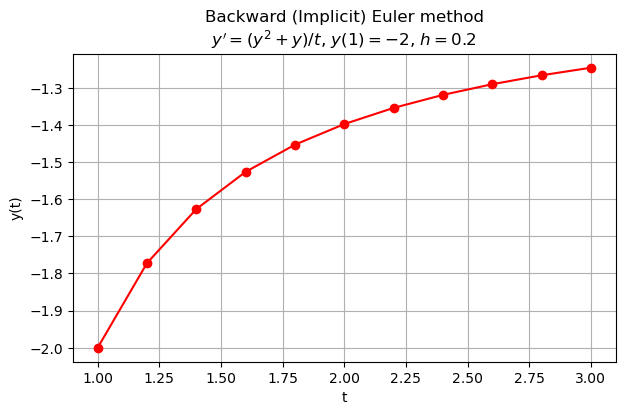

In [36]:
# Print results
print(" n    t      y")
for n in range(N):
    print(f"{n:2d}  {t_values[n]:.1f}  {y[n]:.6f}")

# Plot
plt.figure(figsize=(7,4))
plt.plot(t_values, y, marker='o', linestyle='-', color='r')
plt.title("Backward (Implicit) Euler method\n$y'=(y^2+y)/t$, $y(1)=-2$, $h=0.2$")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)
plt.show()